## Library Imports

The libraries below will serve much of the core functionality of this analysis.

**Pandas** is a foundational Python library for data manipulation and dataframe operations, 
crucial for any data analysis workflow.

**NumPy** enables powerful vectorised and matrix mathematics in Python. Unlike R, Python 
does not have native vectorised operations or a default vector type, so NumPy provides 
the linear algebra and matrix operations required for complex analyses like this one.

**Matplotlib** and **Seaborn** are the visualisation libraries of choice for this analysis. 
Matplotlib provides fine-grained control over plots while Seaborn offers cleaner, 
higher-level statistical visualisations. I personally like to use both in Data Analysis.

**Scikit-learn** is a world-renowned machine learning library that abstracts much of the 
underlying statistical and mathematical complexity behind clean function calls. This 
analysis uses **Logistic Regression** as the primary classification model, with an initial decision 
threshold of 50%, to predict whether a given comment constitutes toxic content.

A **Naive Bayes** model is also evaluated as a baseline for comparison.


In [44]:
# Import packages
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score, ConfusionMatrixDisplay
from sklearn.feature_extraction.text import TfidfVectorizer
import warnings
warnings.filterwarnings('ignore')

## Data Loading

In [3]:
# Read csv into a dataframe 
df = pd.read_csv("train.csv")
df.head()

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


In [4]:
df.describe()

,toxic,severe_toxic,obscene,threat,insult,identity_hate
count,159571.000000,159571.000000,159571.000000,159571.000000,159571.000000,159571.000000
mean,0.095844,0.009996,0.052948,0.002996,0.049364,0.008805
std,0.294379,0.099477,0.223931,0.054650,0.216627,0.093420
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## Dataset Description

This dataset contains ~160,000 Wikipedia talk page comments, labelled by human raters across six toxicity categories:

- **toxic** — general toxicity
- **severe_toxic** — extreme toxicity
- **obscene** — obscene language
- **threat** — threatening language
- **insult** — personal insults
- **identity_hate** — attacks on identity characteristics

It was originally a Kaggle competition run by Jigsaw/Google in 2018.

Based on the descriptive statistics from the describe method in pandas, we can see that certain toxicity classifications occur more often than others. For example, `toxic` occurs ~10% of the time across the dataset. Meaning that roughly 16,000 comments were classified as toxic. `severe_toxic` on the other hand, occurs ~1% of the time across the dataset, a numerical equivalent of roughly 1,600 comments.

`threat` occurs least frequently across our data, at approximately 0.3% occurrence, which equates to 
roughly 480 comments. The `insult`, `identity_hate` and `obscene` classes occur 
approximately 5%, 0.9% and 5% of the time across all comments respectively. Class imbalance is an anticipated concern given the rarity of toxic comments in this dataset, and will need to be handled. 

It is clear that the above output is not going to serve our binary logistic regression model. The reason being we have 6 different classification metrics. We need one dependent variable for logistic regression. The decision has therefore been made to collapse all toxicity labels into a column called **toxic_any**, and label this 1 if any toxicity measurement is present for the comment, and 0 otherwise. This loses some nuance and granularity, but the model we want to build is a binary classifier, answering the question: "Is this a toxic comment or not?".

In [5]:
# Create a binary target variable, which will be 1 if any toxicity label is present.
df['toxic_any'] = (df[['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']].sum(axis=1) > 0).astype(int)

# Check for missing values 
df['comment_text'].isnull().sum()

np.int64(0)

In [6]:
# Check for class imbalance (this will likely be present based on summary statistics)
df['toxic_any'].value_counts()

toxic_any
0    143346
1     16225
Name: count, dtype: int64

**Class Imbalance** 

The `toxic_any` variable confirms a significant class imbalance, with approximately 90% of 
comments classified as clean (0) and 10% as toxic (1). 

Class imbalance is a massive statistical concern here and will need to be handled, potentially via weighting the minority class higher. Without some handeling, an intercept only, "null" logistic regression model, would be as accurate as the percentage of the majority class. This is not good.

In other words, a naive model that predicted "clean" (0) for every comment would achieve 90% accuracy while 
being entirely useless for detecting toxic content. For this reason, accuracy alone is a 
misleading metric here.

To address this, `class_weight='balanced'` will be passed to the Logistic Regression 
model, which automatically weights the minority class (toxic comments) higher during 
training. Precision, Recall and ROC-AUC will be used as the primary evaluation metrics 
rather than accuracy.

## Preprocessing

In [20]:
# Preprocessing - starting with dropping cols we no longer need
df = df[["comment_text", "toxic_any"]]
df.head()

,comment_text,toxic_any
0,Explanation\nWhy the edits made under my usern...,0
1,D'aww! He matches this background colour I'm s...,0
2,"Hey man, I'm really not trying to edit war. It...",0
3,"""\nMore\nI can't make any real suggestions on ...",0
4,"You, sir, are my hero. Any chance you remember...",0


In [7]:
# Clean text: lowercase, remove non-letter characters, and normalize whitespace (key for modelling)
df["comment_text"] = (
    df["comment_text"]
    .str.lower()
    .str.replace(r'[^a-z\s]', '', regex=True)
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
)


In [8]:
# I will now verify this pre-processing very quickly
df['comment_text'].head(10)

0    explanation why the edits made under my userna...
1    daww he matches this background colour im seem...
2    hey man im really not trying to edit war its j...
3    more i cant make any real suggestions on impro...
4    you sir are my hero any chance you remember wh...
5    congratulations from me as well use the tools ...
6         cocksucker before you piss around on my work
7    your vandalism to the matt shirvington article...
8    sorry if the word nonsense was offensive to yo...
9    alignment on this subject and which are contra...
Name: comment_text, dtype: object

In [9]:
# See how much data ended up as empty strings
(df['comment_text'] == '').sum()

np.int64(7)

With only **7** rows ending up as empty strings after the normalisation pre-processing, and a manual inspection of 10 rows of the `comment_text` column confirming that pre-processing has worked, we can be confident that our normalisation steps have worked effectively. 

**Steps Undertaken**:

- **Lowercasing:** All text was converted to lowercase using `.str.lower()` to ensure consistency and avoid duplicate tokens (e.g., "Word" vs "word").

- **Regex cleaning:** All characters outside lowercase letters (`a–z`) and whitespace were removed from the `comment_text` column using regular expressions. This reduces noise and ensures cleaner input for vectorization.

- **Whitespace normalization:** Multiple consecutive whitespace characters were replaced with a single space using regex, and leading/trailing spaces were removed.

This will ensure that all text passed to **TF-IDF** is standardised and free from unnecessary noise.

In [15]:
# Split data before applying TF-IDF...
X_train, X_test, y_train, y_test = train_test_split(
    df['comment_text'],   
    df['toxic'],          
    test_size=0.2,
    random_state=42
)

# Initialize TF-IDF vectorizer (stop word removal, ngrams 1 and 2 and max features included too).
vectorizer = TfidfVectorizer(
    stop_words='english',   
    ngram_range=(1, 2),     
    max_features=10000     
)

# Fit the vectorizer on training data and transform both training and test data
X_train_tfidf = vectorizer.fit_transform(X_train)

# Transform test data
X_test_tfidf = vectorizer.transform(X_test)

**Train-Test Split**

A standard train test split of 80/20 was applied in this dataset, leveraging scikit-learn's `train_test_split` functionality. Random state 42 is included here to ensure reproducability. The idea being setting the seed to ensure the same data split can be obtained consistently.

## Feature Engineering (TF-IDF)

To convert the preprocessed text into a numerical format suitable for modelling, **TF-IDF (Term Frequency–Inverse Document Frequency)** was applied.

**TF-IDF (Term Frequency-Inverse Document Frequency)** is used to represent comments as 
numerical vectors for the model. TF-IDF weights words by how frequently they appear in 
a given comment, offset by how commonly they appear across all comments in the dataset. TF-IDF 
ensures common words like *the*, *and*, *is* are down-weighted relative to more 
meaningful terms. For example, if the word "flamingo" appears frequently within a comment but rarely across the dataset, TF-IDF assigns it a higher weight, indicating its importance in characterising the content of that comment. This representation allows the model to learn patterns associated with toxic language while remaining computationally efficient and interpretable.

TF-IDF is a naive representation in several ways, for example it ignores word order and cannot 
handle polysemous words (the word *"head"* in *"I hit my head"* and *"Sara was head of 
the company"* are treated identically) - but it remains effective for toxicity 
classification tasks like this one. 

For a more context aware analysis, **Transformer based models** such as **BERT** would be far superior. But this would require significant compute, likely slowing down local machines. **BERT** also requires fine-tuning. 
For the sake of a parsimony and statistically interpretable result, **TF-IDF** was chosen instead.

TF-IDF assigns higher importance to words that are frequent in a specific document but less common across the entire dataset, making it particularly effective for text classification tasks such as toxicity detection.

A range of n-gram configurations were explored to capture both individual words and short phrases:

- **Unigrams (1-grams):** Capture individual words.
- **Bigrams (2-grams):** Capture short word sequences that provide additional context (e.g., "you are", "this is").

Stop words were optionally removed to reduce noise and improve model performance.

The resulting TF-IDF matrix was used as input for the Logistic Regression model.

In [38]:
# Define and fit logistic regression model
model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [39]:
# Define and fit Naive Bayes model
baseline_model = MultinomialNB()
baseline_model.fit(X_train_tfidf, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


## Models & Regularisation  
A Logistic Regression model with L2 regularisation (Ridge) was trained on the TF-IDF features. The solver was set to `lbfgs` with a maximum of 1000 iterations to ensure convergence. A fixed `random_state` was used to ensure reproducibility. Logistic Regression assumes a linear relationship between the input features and the log-odds of the target variable.

**Regularisation** 

L2 regularisation was applied to prevent overfitting by penalising large coefficients while retaining all features. This approach is well-suited to high-dimensional data such as TF-IDF representations, as it helps improve model stability and generalisation.

**Baseline Model**

A Multinomial Naive Bayes model was also trained as a baseline for comparison using the same TF-IDF features, with no regularisation. Naive Bayes assumes conditional independence between features, providing a simple probabilistic benchmark against the Logistic Regression model. Multinomial Naive Bayes was trained with default smoothing (alpha = 1.0) to ensure numerical stability and no zero probability occurances.

Accuracy: 0.9555694814350619
              precision    recall  f1-score   support

           0       0.96      0.99      0.98     28859
           1       0.91      0.60      0.72      3056

    accuracy                           0.96     31915
   macro avg       0.93      0.79      0.85     31915
weighted avg       0.95      0.96      0.95     31915



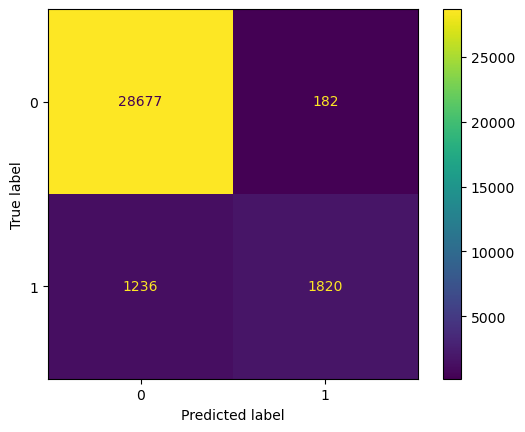

In [45]:
# Predictions for logistic regression
y_pred = model.predict(X_test_tfidf)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Full report
print(classification_report(y_test, y_pred))

# Confusion matrix
ConfusionMatrixDisplay.from_estimator(model, X_test_tfidf, y_test)
plt.show()

Accuracy: 0.9476421745260849
              precision    recall  f1-score   support

           0       0.95      1.00      0.97     28859
           1       0.93      0.49      0.64      3056

    accuracy                           0.95     31915
   macro avg       0.94      0.74      0.81     31915
weighted avg       0.95      0.95      0.94     31915



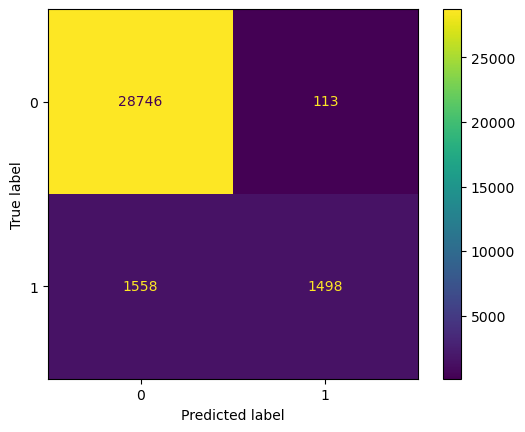

In [46]:
# Predictions for Naive Bayes
y_pred_nb = baseline_model.predict(X_test_tfidf)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred_nb))

# Full report
print(classification_report(y_test, y_pred_nb))

ConfusionMatrixDisplay.from_estimator(baseline_model, X_test_tfidf, y_test)
plt.show()

## Initial Model Evaluation 
The Logistic Regression model achieved an accuracy of 95.6%. However, due to class imbalance, additional metrics provide a more meaningful evaluation.

For the toxic class (label 1), the model achieved a precision of 0.91, indicating that when it predicts a comment as toxic, it is usually correct. However, the recall is 0.60, meaning that approximately 40% of toxic comments are not being detected.

This suggests that while the model is effective at avoiding false positives, it struggles to identify all toxic content, which may be a limitation depending on the use case.

The Multinomial Naive Bayes model achieved an accuracy of 94.8%. For the toxic class, it achieved a higher precision of 0.93, indicating that its toxic predictions are slightly more reliable than Logistic Regression. However, it has significantly lower recall at 0.49, meaning that over 50% of toxic comments are not detected.

**Confusion Matrix Analysis**

The Logistic Regression confusion matrix shows that the model correctly identified a large proportion of non-toxic comments (true negatives), with relatively few false positives (182). However, there are still a notable number of false negatives (1236), meaning some toxic comments were missed. This aligns with the recall of 0.60 for the toxic class, indicating that while the model performs well overall, there is still room for improvement in detecting all toxic instances.

The Naive Bayes model produces fewer false positives (113), indicating higher precision, but a significantly higher number of false negatives (1558), meaning it misses more toxic comments. This is reflected in the lower recall (0.49), suggesting it is less suitable for applications where detecting toxic content is the priority

## Threshold Analysis and Model Refinement (Experimental Evaluation)
Based on these results, Logistic Regression was selected as the primary model for further optimisation.

To improve its effectiveness, different classification thresholds were explored. The objective was to increase recall and capture more toxic content, while maintaining a reasonable balance with precision.

In [24]:
# Adjust classification threshold to increase recall...
# Get predicted probabilities
y_probs = model.predict_proba(X_test_tfidf)[:, 1]

# Lower threshold (e.g. 0.3 instead of 0.5)
y_pred_adjusted = (y_probs >= 0.3).astype(int)

print(classification_report(y_test, y_pred_adjusted))

              precision    recall  f1-score   support

           0       0.97      0.98      0.98     28859
           1       0.82      0.71      0.76      3056

    accuracy                           0.96     31915
   macro avg       0.89      0.85      0.87     31915
weighted avg       0.96      0.96      0.96     31915



After adjusting the classification threshold, the model shows an improved recall for the `toxic` class, increasing from **0.61** to **0.71.** This indicates that the model is now able to identify a higher proportion of toxic comments.

However, this comes at the cost of a decrease in precision, which has dropped from **0.90** to **0.82.** This means that the model produces more false positives, incorrectly classifying some non-toxic comments as toxic.

Overall, this reflects a typical trade-off between precision and recall, where improving the detection of toxic content leads to a slight reduction in prediction precision.

In this context, improved recall is often preferred, as failing to detect toxic content (false negatives) can be more problematic than incorrectly flagging non-harmful content.

**Pre-processing Improvements** 

I will now focus on adjusting the TF-IDF pre-processing steps to try squeeze more predictive power from the logistic regression model.

In [50]:
# Declare vectorizer, with increased features, and min and max document frequencies
vectorizer = TfidfVectorizer(
    stop_words='english',
    ngram_range=(1, 2),
    max_features=20000,
    min_df=2,
    max_df=0.9
)

# Fit the vectorizer on training data and then transform both training and test columns
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# Set up logistic regression model with class_weight = balanced to weight minority class higher
model = LogisticRegression(
    penalty='l2',
    solver='lbfgs',
    max_iter=1000,
    class_weight='balanced'
)

# Train the model
model.fit(X_train_tfidf, y_train)

# Test and evaluate model
y_pred = model.predict(X_test_tfidf)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.94      0.96     28859
           1       0.62      0.85      0.72      3056

    accuracy                           0.94     31915
   macro avg       0.80      0.90      0.84     31915
weighted avg       0.95      0.94      0.94     31915



Following the feature engineering improvements and balanced class-weight adjustment, the model demonstrates a significant improvement in recall for the toxic class, increasing to 0.85. This indicates that the model is now correctly identifying the majority of toxic comments.

However, this comes at the cost of reduced precision once again (0.62), as the model becomes more sensitive and consequently produces a higher number of false positives.


Threshold: 0.6
              precision    recall  f1-score   support

           0       0.98      0.96      0.97     28859
           1       0.69      0.80      0.75      3056

    accuracy                           0.95     31915
   macro avg       0.84      0.88      0.86     31915
weighted avg       0.95      0.95      0.95     31915



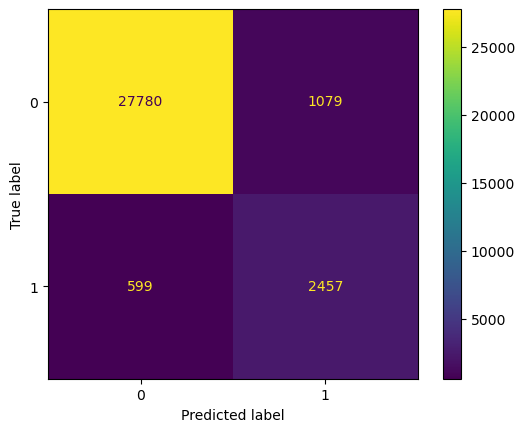


Threshold: 0.5
              precision    recall  f1-score   support

           0       0.98      0.94      0.96     28859
           1       0.62      0.85      0.72      3056

    accuracy                           0.94     31915
   macro avg       0.80      0.90      0.84     31915
weighted avg       0.95      0.94      0.94     31915



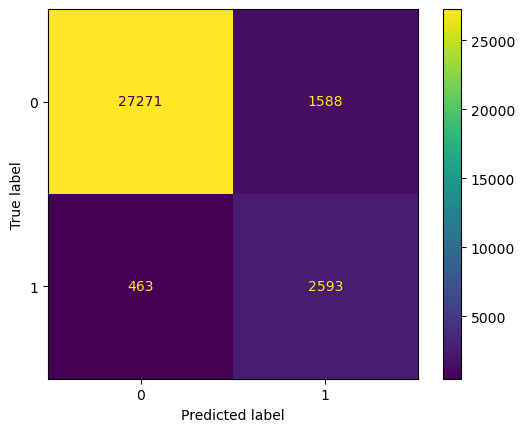


Threshold: 0.4
              precision    recall  f1-score   support

           0       0.99      0.92      0.95     28859
           1       0.53      0.88      0.66      3056

    accuracy                           0.91     31915
   macro avg       0.76      0.90      0.81     31915
weighted avg       0.94      0.91      0.92     31915



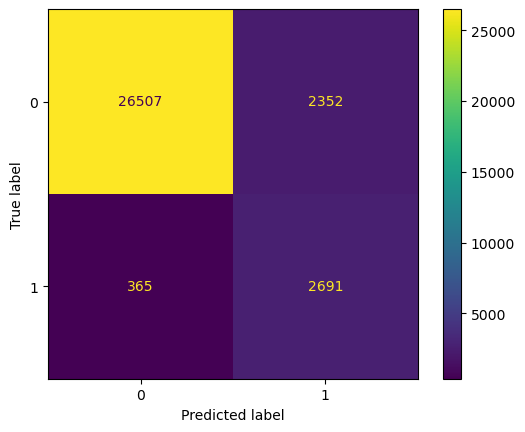


Threshold: 0.3
              precision    recall  f1-score   support

           0       0.99      0.88      0.93     28859
           1       0.44      0.92      0.60      3056

    accuracy                           0.88     31915
   macro avg       0.72      0.90      0.77     31915
weighted avg       0.94      0.88      0.90     31915



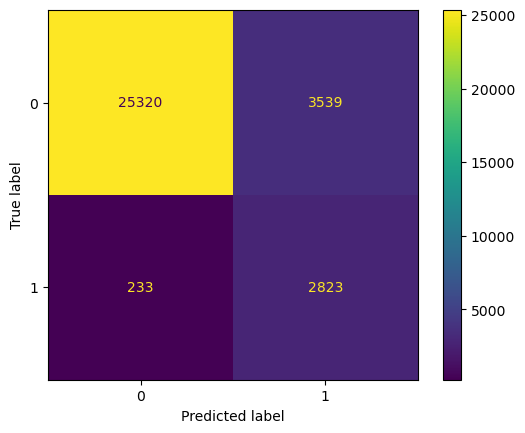


Threshold: 0.2
              precision    recall  f1-score   support

           0       0.99      0.80      0.89     28859
           1       0.33      0.96      0.50      3056

    accuracy                           0.81     31915
   macro avg       0.66      0.88      0.69     31915
weighted avg       0.93      0.81      0.85     31915



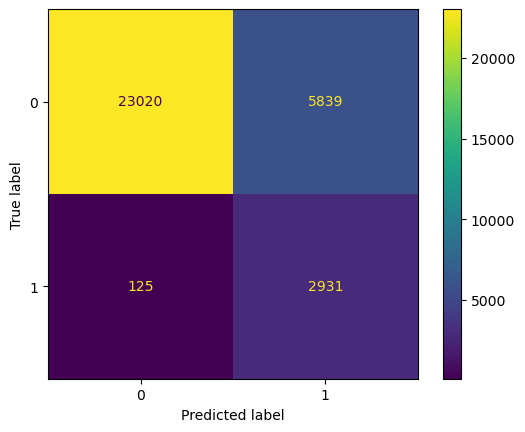

In [54]:
# Try a number of probability thresholds 
thresholds = [0.6, 0.5, 0.4, 0.3, 0.2]

y_probs = model.predict_proba(X_test_tfidf)[:, 1]

for t in thresholds:
    y_pred = (y_probs >= t).astype(int)
    print(f"\nThreshold: {t}")
    print(classification_report(y_test, y_pred))
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
    plt.show()

### Final Model Selection and Threshold Optimisation

To further optimise model performance, different classification thresholds were evaluated. Lowering the threshold increased recall for the toxic class, enabling the model to identify a greater proportion of toxic comments.

However, this improvement came at the cost of reduced precision, as more non-toxic comments were incorrectly classified as toxic.

A threshold of 0.6 provided a strong balance between precision and recall, achieving a precision of 0.69, a recall of 0.80, and an F1-score of 0.75 for the toxic class. This threshold was therefore selected as the optimal operating point based on this trade-off.

The model was trained using an enhanced TF-IDF representation, incorporating n-grams, controlled document frequency thresholds (min_df and max_df), and increased feature dimensionality. In addition, class imbalance was addressed using class weighting in the Logistic Regression model, ensuring that the minority (toxic) class was appropriately prioritised during training.

These improvements were applied as part of a combined modelling pipeline rather than in isolation, with each component contributing to the overall performance of the final model.

## Discussion of Trade-offs
The optimal model depends on the application: higher recall may be preferred in content moderation systems to minimise the risk of harmful content being missed, while higher precision may be preferred in scenarios where false positives are costly.

An earlier model achieved a precision of 0.82 and a recall of 0.71, with an F1-score of 0.76. While this represents a more balanced performance overall, a model with slightly lower F1 but higher recall may be preferable when prioritising the detection of toxic content.

This highlights the importance of aligning model selection and evaluation metrics with the specific objectives of the system, rather than relying solely on aggregate performance measures.

**Future Imporvements**

Future improvements of this analysis could include exploring more advanced models such as linear SVMs or deep learning approaches.
